<a href="https://colab.research.google.com/github/Agtna/AI-2025/blob/main/UTSAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('./airbnb.csv')
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [14]:
df = pd.read_csv('./airbnb.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [10]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [11]:
price_series = pd.Series([149, 225, 150, 89, 80, 200, 140, 79, 79, 150,
135],
  index=[
    "Clean & quiet apt home by the park",
    "Skylit Midtown Castle",
    "THE VILLAGE OF HARLEM...NEW YORK",
    "Cozy Entire Floor of Brownstone",
    "Entire Apt: Spacious Studio/Loft by central park",
    "Large Cozy 1 BR Apartment In Midtown East",
    "BlissArtsSpace",
    "Large Furnished Room Near B'way ",
    "Cozy Clean Guest Room - Family Apt",
    "Cute & Cozy Lower East Side 1 bdrm",
    "Beautiful 1br on Upper West Side"
    ]
  )
print(price_series)

Clean & quiet apt home by the park                  149
Skylit Midtown Castle                               225
THE VILLAGE OF HARLEM...NEW YORK                    150
Cozy Entire Floor of Brownstone                      89
Entire Apt: Spacious Studio/Loft by central park     80
Large Cozy 1 BR Apartment In Midtown East           200
BlissArtsSpace                                      140
Large Furnished Room Near B'way                      79
Cozy Clean Guest Room - Family Apt                   79
Cute & Cozy Lower East Side 1 bdrm                  150
Beautiful 1br on Upper West Side                    135
dtype: int64


In [12]:
import pandas as pd
df = pd.DataFrame([149, 225, 150, 89, 80, 200, 140, 79, 79, 150, 135],
  index=[
    "Clean & quiet apt home by the park",
    "Skylit Midtown Castle",
    "THE VILLAGE OF HARLEM...NEW YORK",
    "Cozy Entire Floor of Brownstone",
    "Entire Apt: Spacious Studio/Loft by central park",
    "Large Cozy 1 BR Apartment In Midtown East",
    "BlissArtsSpace",
    "Large Furnished Room Near B'way ",
    "Cozy Clean Guest Room - Family Apt",
    "Cute & Cozy Lower East Side 1 bdrm",
    "Beautiful 1br on Upper West Side" ])
df

,0
Clean & quiet apt home by the park,149
Skylit Midtown Castle,225
THE VILLAGE OF HARLEM...NEW YORK,150
Cozy Entire Floor of Brownstone,89
Entire Apt: Spacious Studio/Loft by central park,80
Large Cozy 1 BR Apartment In Midtown East,200
BlissArtsSpace,140
Large Furnished Room Near B'way,79
Cozy Clean Guest Room - Family Apt,79
Cute & Cozy Lower East Side 1 bdrm,150


In [15]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [28]:
for col in df.select_dtypes(include=['number']).columns:
  print(f"Kolom: {col}")
  print(f" Mean : {df[col].mean()}")
  print(f" Median : {df[col].median()}")
  print(f" Std Dev : {df[col].std()}")
  print(f" Min : {df[col].min()}")
  print(f" Max : {df[col].max()}")
  print(f" Range : {df[col].max() - df[col].min()}")
  print(f" Rasio Max/Min : {df[col].max() / df[col].min() if df[col].min() != 0 else 'N/A'}")
  print("-" * 40)

Kolom: id
 Mean : 19017143.236179568
 Median : 19677284.0
 Std Dev : 10983108.38561011
 Min : 2539
 Max : 36487245
 Range : 36484706
 Rasio Max/Min : 14370.714848365498
----------------------------------------
Kolom: host_id
 Mean : 67620010.64661008
 Median : 30793816.0
 Std Dev : 78610967.03266686
 Min : 2438
 Max : 274321313
 Range : 274318875
 Rasio Max/Min : 112518.99630844955
----------------------------------------
Kolom: latitude
 Mean : 40.72894888066264
 Median : 40.72307
 Std Dev : 0.054530078057371895
 Min : 40.49979
 Max : 40.91306
 Range : 0.41327000000000425
 Rasio Max/Min : 1.0102042504417925
----------------------------------------
Kolom: longitude
 Mean : -73.95216961468454
 Median : -73.95568
 Std Dev : 0.04615673610637182
 Min : -74.24442
 Max : -73.71299
 Range : 0.5314300000000003
 Rasio Max/Min : 0.9928421556798477
----------------------------------------
Kolom: price
 Mean : 152.7206871868289
 Median : 106.0
 Std Dev : 240.15416974718727
 Min : 0
 Max : 10000
 R

In [29]:
idx_min = df['price'].idxmin()
print("Index harga paling rendah:", idx_min)
print("Data baris dengan harga paling rendah:")
print(df.loc[idx_min])
idx_max = df['price'].idxmax()
print("Index harga paling tinggi:", idx_max)
print("Data baris dengan harga paling tinggi:")
print(df.loc[idx_max])

Index harga paling rendah: 23161
Data baris dengan harga paling rendah:
id                                                                         18750597
name                              Huge Brooklyn Brownstone Living, Close to it all.
host_id                                                                     8993084
host_name                                                                  Kimberly
neighbourhood_group                                                        Brooklyn
neighbourhood                                                    Bedford-Stuyvesant
latitude                                                                   40.69023
longitude                                                                 -73.95428
room_type                                                              Private room
price                                                                             0
minimum_nights                                                                    4
numb

Matlotlib

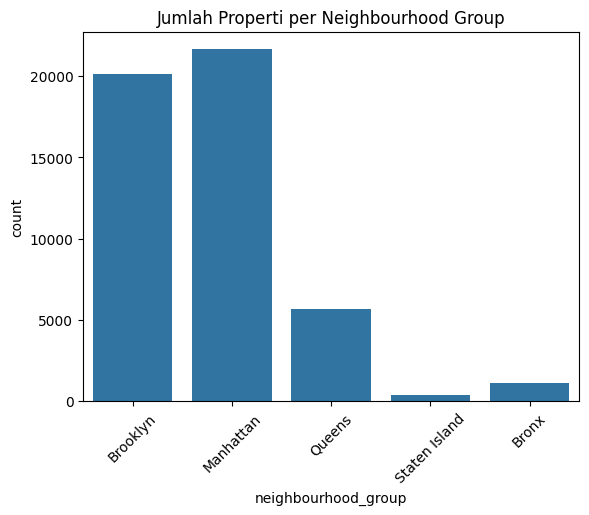

In [44]:
# Jumlah properti berdasarkan neighbourhood_group
sns.countplot(data=df, x='neighbourhood_group')
plt.title("Jumlah Properti per Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()

bar chart

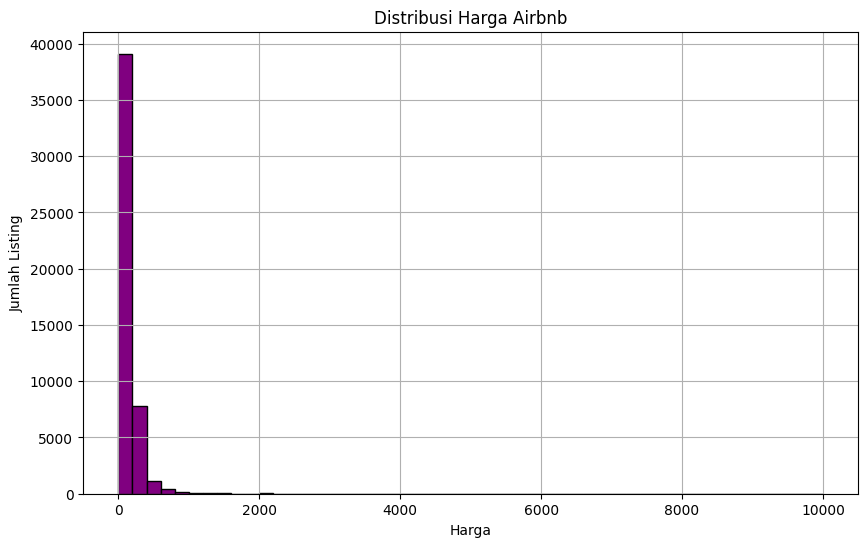

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('airbnb.csv')
df['price'] = df['price'].fillna(df['price'].mean())
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50, color='purple', edgecolor='black')
plt.title('Distribusi Harga Airbnb')
plt.xlabel('Harga')
plt.ylabel('Jumlah Listing')
plt.grid(True)
plt.show()

Pie Chart

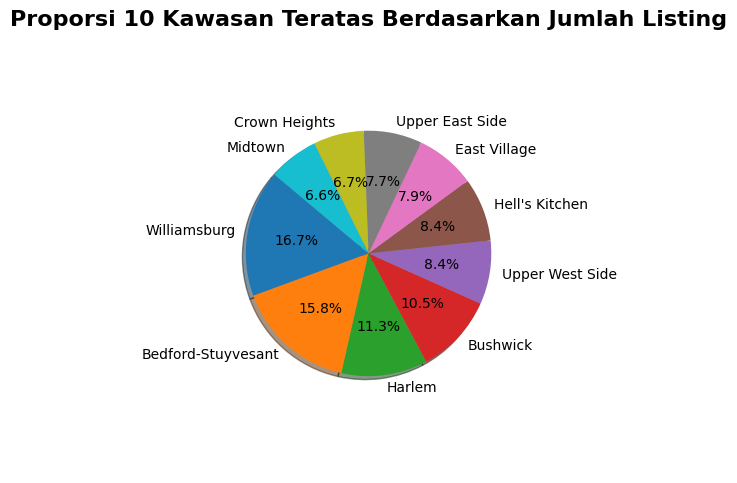

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('airbnb.csv')
neighbourhood_counts = df['neighbourhood'].value_counts().head(10)
plt.figure(figsize=(5, 5))
plt.pie(neighbourhood_counts, labels=neighbourhood_counts.index,
autopct='%1.1f%%',
startangle=140, shadow=True)
plt.title('Proporsi 10 Kawasan Teratas Berdasarkan Jumlah Listing',
fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

line chart

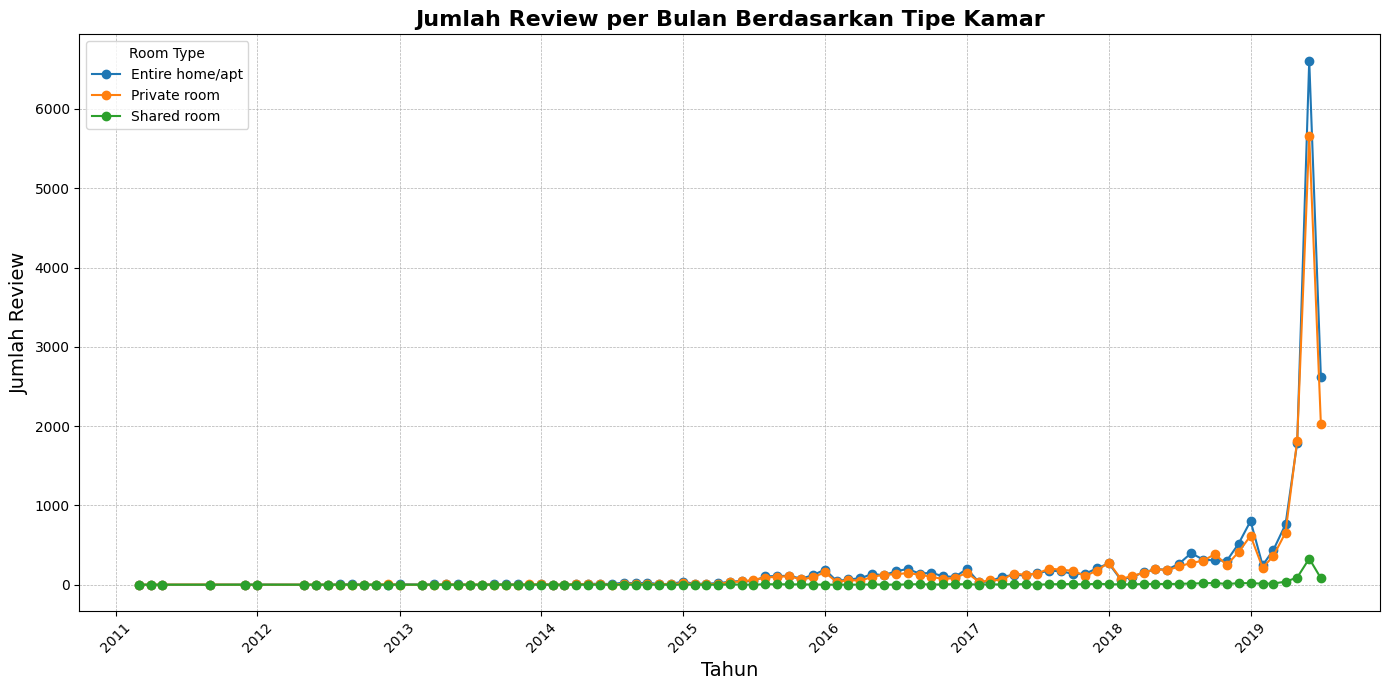

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data dari file CSV
df = pd.read_csv('airbnb.csv')

# Mengubah kolom 'last_review' menjadi format datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Menambahkan kolom 'review_month' berdasarkan bulan dari 'last_review'
df['review_month'] = df['last_review'].dt.to_period('M')

# Menghapus baris yang memiliki nilai NaN pada kolom 'review_month' dan 'room_type'
df_filtered = df.dropna(subset=['review_month', 'room_type'])

# Mengelompokkan data berdasarkan bulan dan tipe kamar, lalu menghitung jumlah review
review_by_type = df_filtered.groupby(['review_month', 'room_type']).size().unstack(fill_value=0)

# Mengubah index dari Period menjadi Timestamp untuk plotting
review_by_type.index = review_by_type.index.to_timestamp()

# Visualisasi data
plt.figure(figsize=(14, 7))
for column in review_by_type.columns:
    plt.plot(review_by_type.index, review_by_type[column], label=column, marker='o')

# Menambahkan judul dan label sumbu
plt.title('Jumlah Review per Bulan Berdasarkan Tipe Kamar', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=14)
plt.ylabel('Jumlah Review', fontsize=14)

# Mengatur grid dan rotasi label x-axis
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)

# Menambahkan legenda
plt.legend(title='Room Type')

# Mengatur layout dan menampilkan plot
plt.tight_layout()
plt.show()


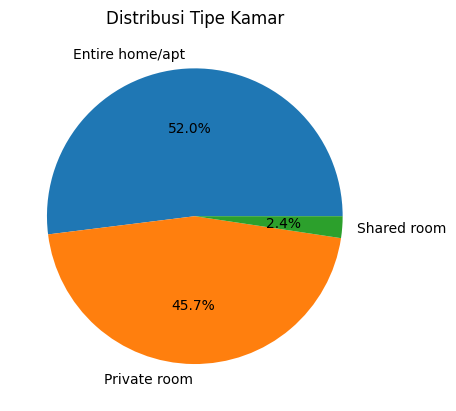

In [41]:
# Distribusi berdasarkan room_type
df['room_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribusi Tipe Kamar")
plt.ylabel("")
plt.show()

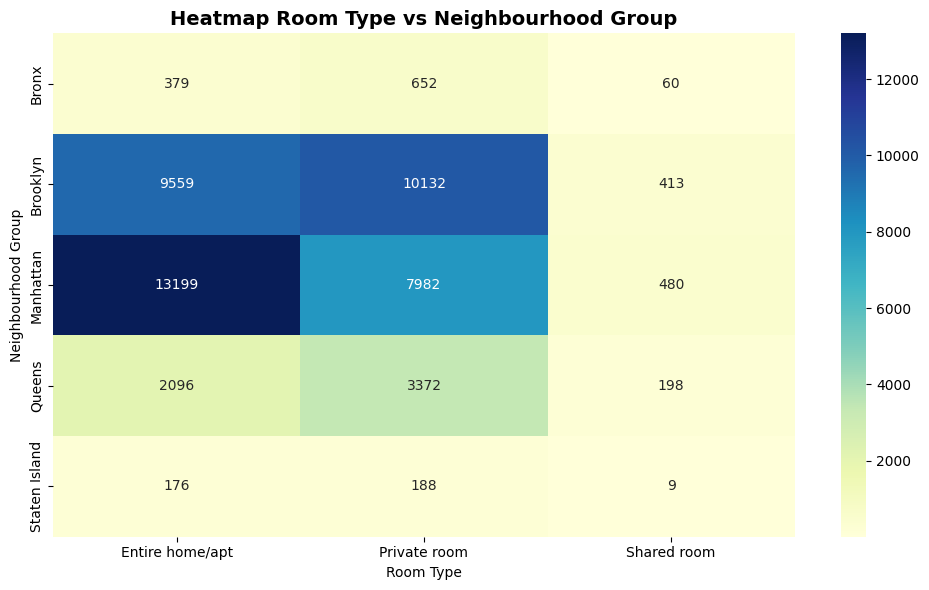

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Membaca data
df = pd.read_csv('airbnb.csv')

# Mengelompokkan data dan membuat tabel pivot
heatmap_data = df.groupby(['neighbourhood_group', 'room_type']).size().unstack()

# Membuat heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')

# Menambahkan judul dan menampilkan plot
plt.title("Heatmap Room Type vs Neighbourhood Group", fontsize=14, fontweight='bold')
plt.xlabel("Room Type")
plt.ylabel("Neighbourhood Group")
plt.tight_layout()
plt.show()
